# EDA -  Bank Marketing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns
from scipy import stats
import os

In [2]:
working_dir = os.getcwd()
path_dados = os.path.join(working_dir, "..", "data/kaggle")

path = os.path.join(path_dados, r"bank-additional-full.csv")
df = pd.read_csv(path, sep=";")
print(df.shape)
df.head()

(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

## 1. Qualidade dos Dados

### A. Missing Values

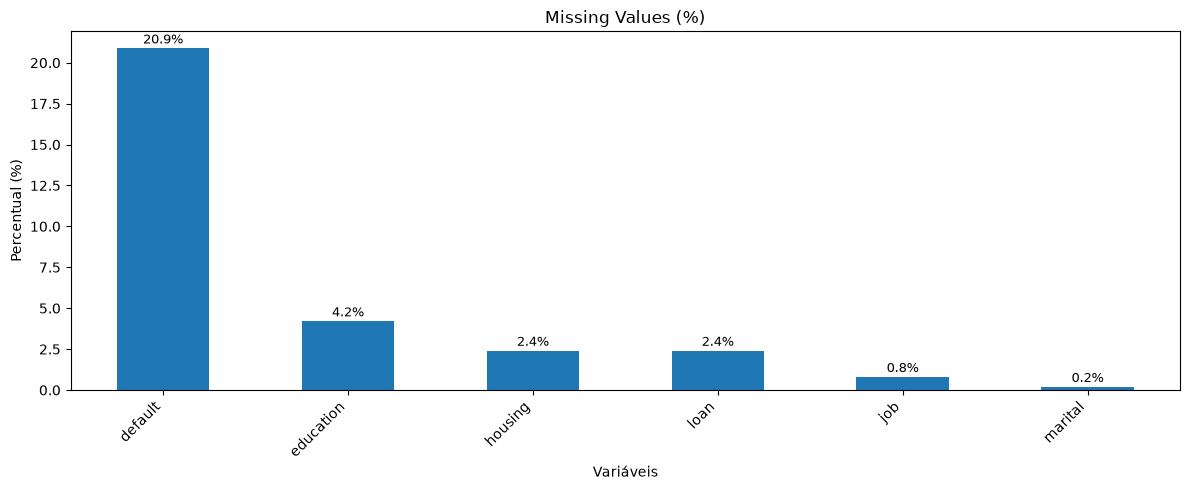

In [4]:
copy = df.copy()
copy = copy.replace("unknown", np.nan) # tratar "unknown" como missing

missing_pct = copy.isnull().mean().sort_values(ascending=False) * 100
missing_pct = missing_pct[missing_pct > 0]

# gráficos:
ax = missing_pct.plot(kind="bar", figsize=(12, 5))

# título e labels
ax.set_title("Missing Values (%)")
ax.set_xlabel("Variáveis")
ax.set_ylabel("Percentual (%)")

# rotacionar labels do eixo x
plt.xticks(rotation=45, ha="right")

# adicionar valores em cima das barras
for i, v in enumerate(missing_pct):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

- A base preencheu os nulos com *'unknown'*. 
- Removendo o unknown, detectamos que o volume de nulos é maior na coluna de *default*, com 20,9%. 
- As demais colunas (*education*, *housing*, *loan*, *job* e *marital*) tem um volume de nulos menor que 5%.

### B. Duplicados

In [5]:
duplicates = df.duplicated().sum()
pct_dup = duplicates / len(df) * 100

print(f"Duplicados: {duplicates} ({pct_dup:.2f}%)")

Duplicados: 12 (0.03%)


- A base possui apenas 12 linhas duplicadas. Elas serão removidas via *drop_duplicates* sem prejudicar a qualidade dos dados.

### C. Outliers e Distribuições

In [6]:
num_cols = df.select_dtypes(include=np.number).columns

outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = outliers

pd.Series(outlier_summary).sort_values(ascending=False)

previous          5625
duration          2963
campaign          2406
pdays             1515
age                469
cons.conf.idx      447
emp.var.rate         0
cons.price.idx       0
euribor3m            0
nr.employed          0
dtype: int64

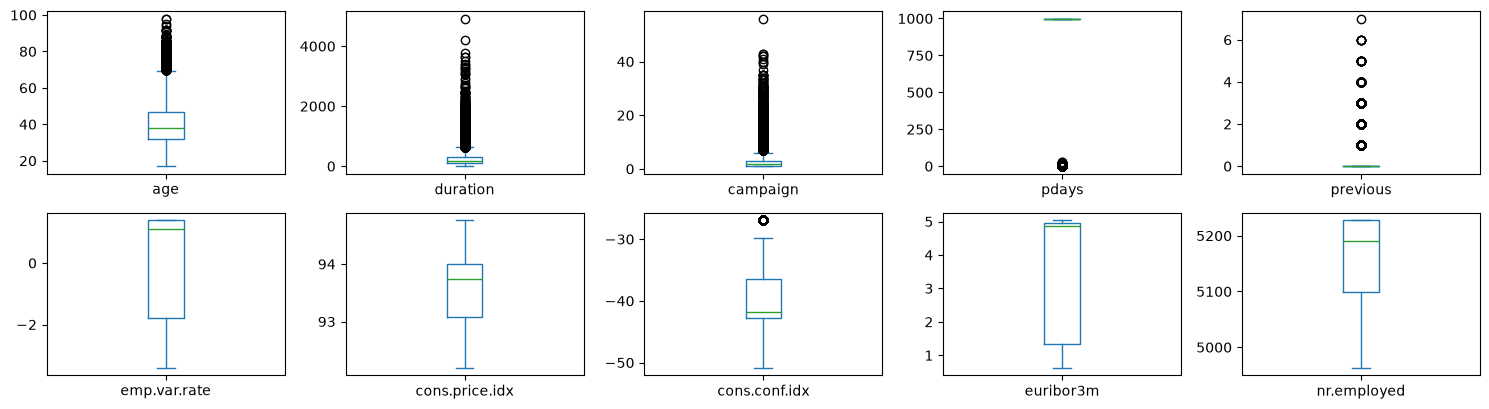

In [7]:
df[num_cols].plot(kind="box", subplots=True, layout=(5,5), figsize=(15,10))
plt.tight_layout()
plt.show()

- A base possui outliers extremos nas colunas:
  - **duration** — Distribuição fortemente assimétrica com outliers massivos (~4000s). É a variável mais crítica. Porém, o próprio dataset do Kaggle avisa que essa variável **não** deve ser usada como feature preditiva em produção, pois só é conhecida após a ligação terminar. **Logo, a coluna será dropada**
  - **campaign** — Outliers chegando a ~40 contatos. A maioria dos clientes recebe 1–3 ligações, então valores acima de ~10 são anômalos e provavelmente ineficazes. **Tratamento via cap, mantendo os registros fixados no quantil 99**
  - **pdays** — O valor 999 é um código que indica que o cliente nunca foi contactado antes. Logo, não é um outlier real. **Tratamento consiste em transformar numa flag binária (*contacted_before*)**
  - **previous** — Indica número de contatos anteriores (variando de 0 a 7). Não é um outlier real.
  
-  A coluna *age* possui poucos outliers e possuem uma distribuição aceitável.
-  As demais colunas são variáveis macroeconômicas e os outliers que existem são reflexo dos ciclos econômicos.

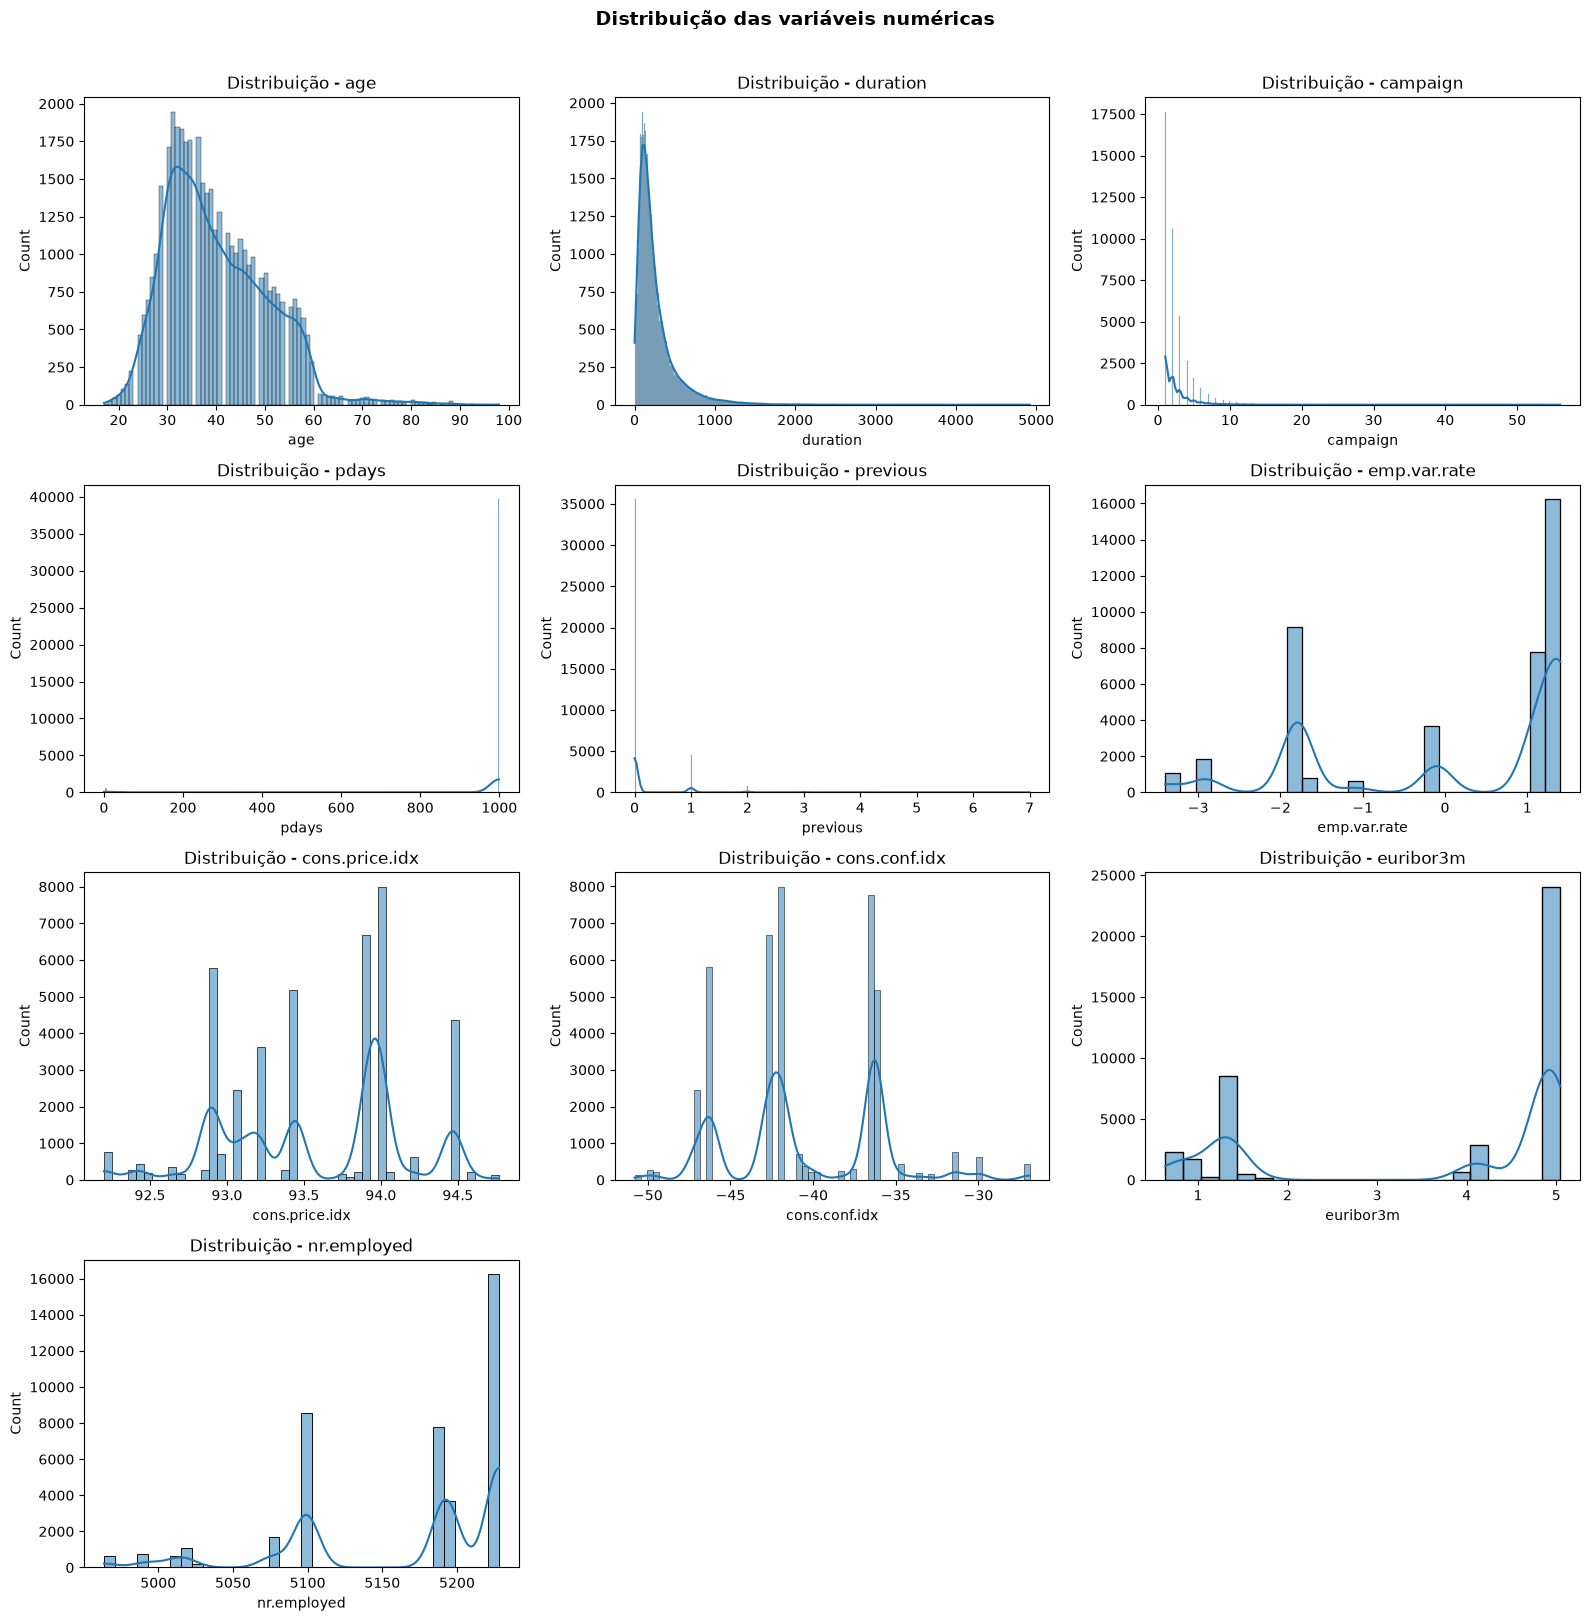

In [8]:
# Distribuições
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

fig.suptitle("Distribuição das variáveis numéricas", 
             fontsize=14, fontweight="bold", y=1.01)

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribuição - {col}")

for k in range(len(num_cols), len(axes)):
    axes[k].set_visible(False)

plt.tight_layout()
plt.show()

- `age` — Assimetria à direita moderada
  - Distribuição unimodal com pico entre **30–35 anos**
  - Cauda direita pronunciada: há clientes acima de 70–80 anos, mas são raros
  - Comportamento típico de base de clientes bancários: maioria adultos jovens/média-idade

- `duration` — Cauda longa extrema 
  - Pico fortíssimo próximo de 0–200 segundos; cauda se estende até ~5000s
  - Distribuição exponencial/log-normal característica de tempo de chamada
  - **Não deve ser usada como feature preditiva**, pois só é conhecida *após* o término da ligação, configurando **data leakage**

- `campaign` — Cauda longa extrema
  - 95%+ dos clientes receberam ≤ 5 ligações; valores chegam a 56
  - Distribuição exponencial típica de esforço de campanha

- `pdays` e `previous` — Encoding disfarçado de variável contínua 
  - `pdays` tem ~96% dos registros têm valor **999** (código especial = "nunca contactado antes"), enquanto que `previous` tem mais de 85% com valor 0 e pouquíssimos registros com 1+

> **Observação geral:** Todas as variáveis macro apresentam distribuição **multimodal**, o que reflete snapshots de períodos econômicos distintos (dados reportados mensalmente/trimestralmente). Isso **não é ruído** — é estrutura real do dado.

- `emp.var.rate` — Bimodal
  - Dois picos bem definidos: em torno de **-2** e **+1**
  - Representa dois regimes econômicos distintos: **recessão vs. expansão**

- `cons.price.idx` — Multimodal com picos discretos
  - Vários picos entre 92.5 e 94.7
  - Dados reportados em períodos fixos mensais — variância é limitada

- `cons.conf.idx` — Bimodal
  - Dois picos: em torno de **-45** e **-35**
  - Alternância entre sentimento do consumidor muito negativo e moderadamente negativo

- `euribor3m` — Bimodal acentuado
  - Dois clusters bem separados: ~**1.3** (juros baixos) e ~**5.0** (juros altos)

- `nr.employed` — Multimodal com clusters
  - Clusters em torno de 5000, 5100 e 5200+
  - Snapshots trimestrais do número de empregados na economia

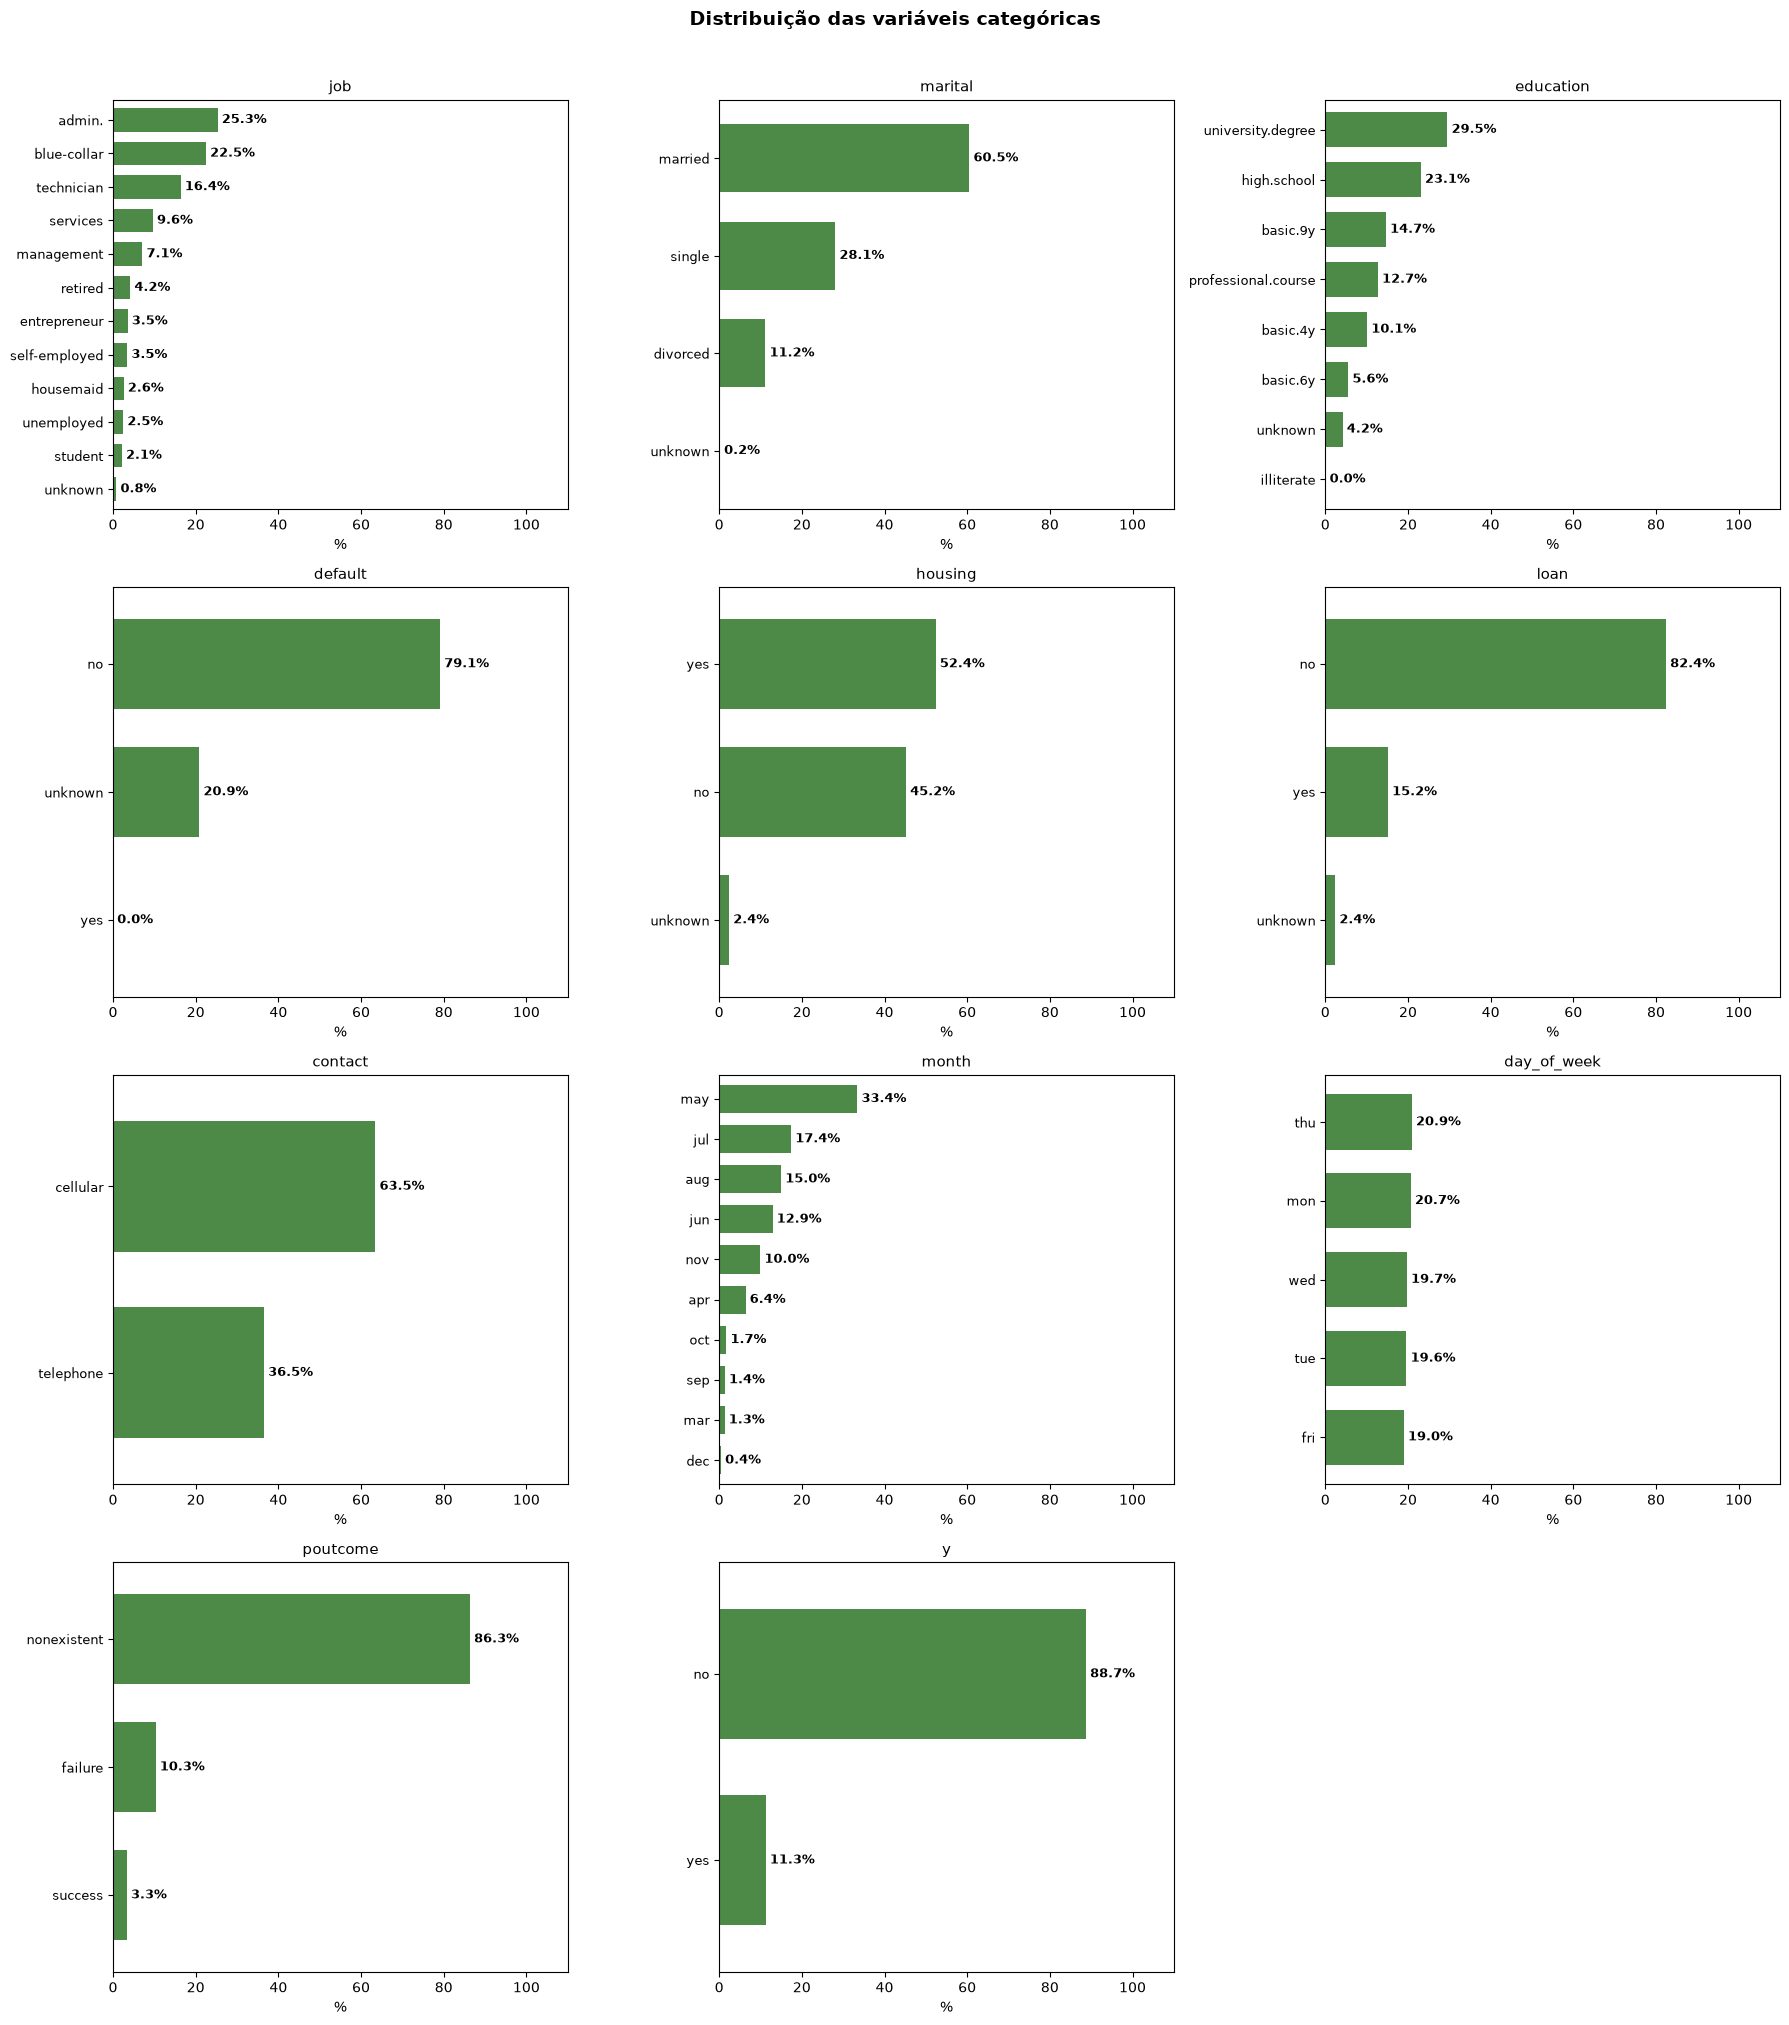

In [9]:
# Distribuição das variáveis categóricas

cat_cols = df.select_dtypes(include="object").columns 
n_cols = 3
n_rows = int(np.ceil(len(cat_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

fig.suptitle("Distribuição das variáveis categóricas", 
             fontsize=14, fontweight="bold", y=1.01)

for i, col in enumerate(cat_cols):
    ax = axes[i]
    
    # percentual (equivalente ao estilo do outro gráfico)
    ct = df[col].value_counts(normalize=True) * 100

    ct.sort_values().plot(
        kind="barh",
        ax=ax,
        color="#4D8A48",
        width=0.7
    )

    ax.set_title(col, fontsize=11)
    ax.set_xlabel("%")
    ax.set_ylabel("")
    ax.set_xlim(0, 110)
    ax.tick_params(axis="y", labelsize=9)

    # remove legenda (não tem target aqui)
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    # rótulos no final das barras
    for container in ax.containers:
        for bar in container:
            w = bar.get_width()
            if w > 0:
                ax.text(
                    w + 1,  # deslocamento para fora da barra
                    bar.get_y() + bar.get_height() / 2,
                    f"{w:.1f}%",
                    ha="left",
                    va="center",
                    fontsize=9,
                    color="black",
                    fontweight="bold"
                )

# remove eixos vazios
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- A base é composta majoritariamente por clientes com **perfil administrativo**, **casados**, com **nível superior**, **sem histórico de inadimplência** (default). Em relação a produtos financeiros, a maior parte possui **financiamento habitacional** (housing), mas **não possui empréstimos pessoais** (loan). O principal canal de contato utilizado é o **telefone celular**.
- Observa-se que o mês de **maio** concentra o **maior volume de chamadas (33,4%)**, enquanto **a distribuição ao longo dos dias da semana é relativamente homogênea**, sem grandes picos. Além disso, **a maioria dos clientes não possui histórico de participação em campanhas anteriores (poutcome = “non-existent”)**.
- A variável **target** apresenta forte **desbalanceamento**, com aproximadamente **90% de casos negativos e apenas 10% positivos**, o que exige atenção especial na modelagem e avaliação dos resultados.

### D. Detecção de Leakage

In [10]:
# correlação com target (numéricas)
if copy["y"].dtype == "object":
    copy["y"] = copy["y"].map({"yes": 1, "no": 0})

# calcular correlação apenas com numéricas
corr = copy.corr(numeric_only=True)["y"].sort_values(ascending=False)

print(corr)

y                 1.000000
duration          0.405274
previous          0.230181
cons.conf.idx     0.054878
age               0.030399
campaign         -0.066357
cons.price.idx   -0.136211
emp.var.rate     -0.298334
euribor3m        -0.307771
pdays            -0.324914
nr.employed      -0.354678
Name: y, dtype: float64


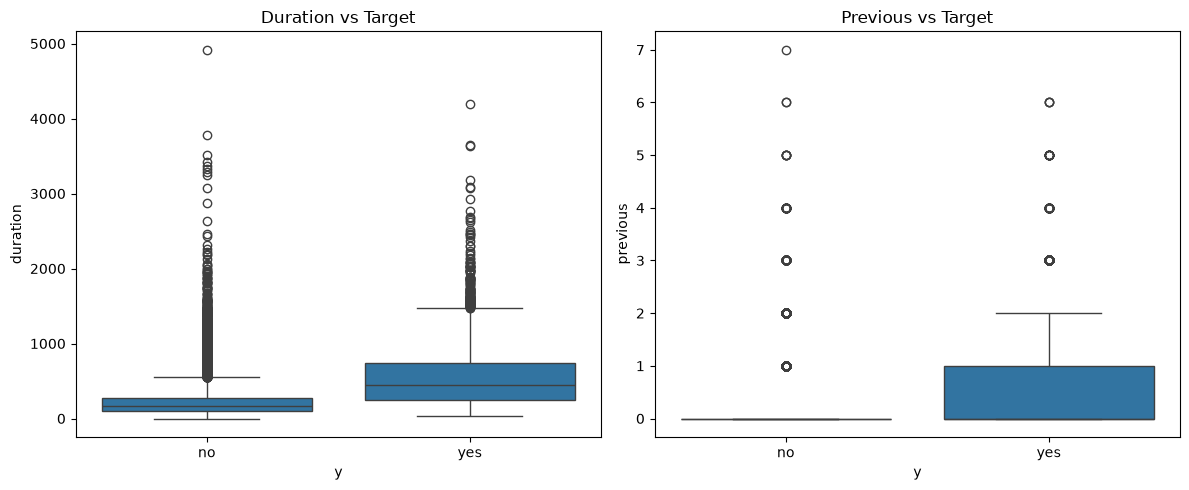

In [11]:
# analisar duration/previous vs target

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x="y", y="duration", data=df, ax=ax[0])
ax[0].set_title("Duration vs Target")

sns.boxplot(x="y", y="previous", data=df, ax=ax[1])
ax[1].set_title("Previous vs Target")

plt.tight_layout()
plt.show()

-  O objetivo dessa análise era confirmar possíveis leakage para além da variável *duration* cujo vazamento já foi apontado pelo dataset no Kaggle.
-  `duration` se configura como leakage devido a alta correlação (0.40) e a clara separação na target, indicando que se a ligação durou muito, é provável que o cliente tenha aceitado.
-  A variável `previous` não é um leakage evidente, mas deve ter cuidado, pois pode apresentar um viés de processo devido o maior número de tentativas.
-  `pdays`, com uma correlação de -0.32 confirma a necessidade de lidar com essa variável como uma flag. 

## 2. Análises dos dados

In [12]:
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.family": "sans-serif",
})
 
# Garante que y é numérico (1/0)
if df["y"].dtype == object:
    df["y"] = (df["y"] == "yes").astype(int)

### A. Segmentação das variáveis categóricas por resultado (y)

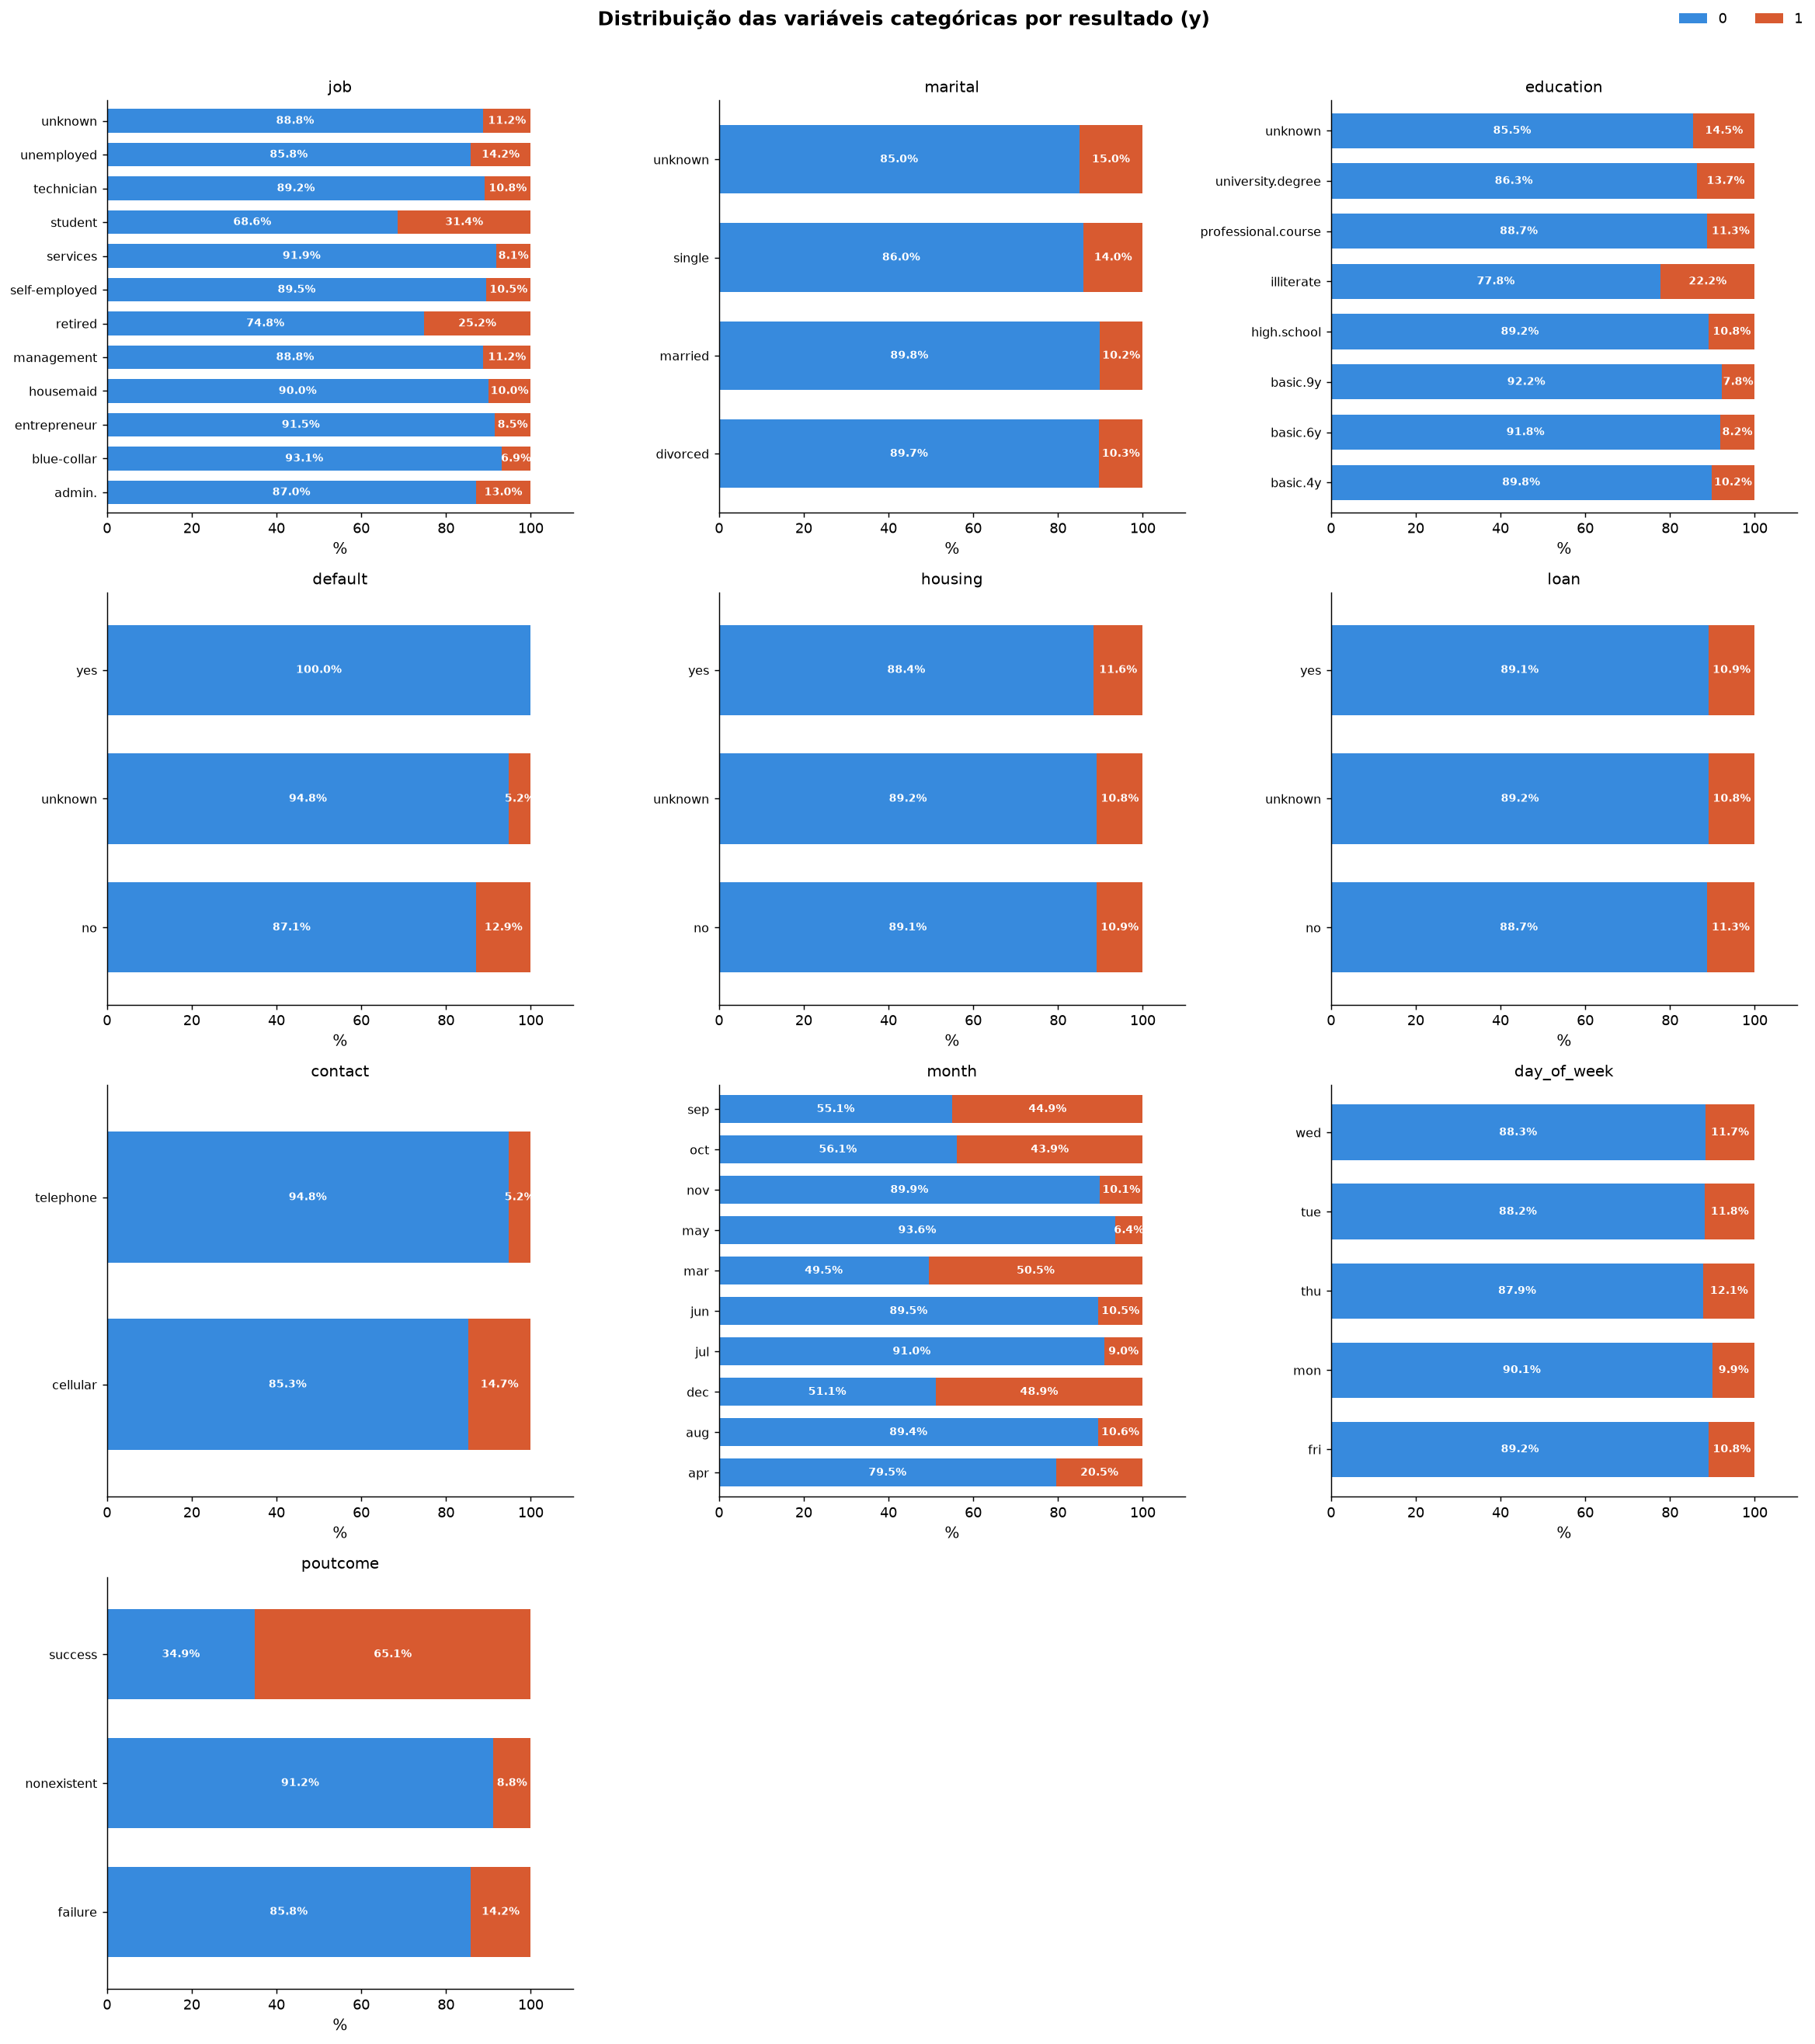

In [13]:
cat_cols_plot = [col for col in cat_cols if col != "y"]

n_cols = 3
n_rows = int(np.ceil(len(cat_cols_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

fig.suptitle("Distribuição das variáveis categóricas por resultado (y)", fontsize=14, fontweight="bold", y=1.01)

for i, col in enumerate(cat_cols_plot):
    ax = axes[i]
    ct = pd.crosstab(df[col], df["y"], normalize="index") * 100

    ct.plot(kind="barh", stacked=True, ax=ax, width=0.7,
            color=["#378ADD", "#D85A30"])

    ax.set_title(col, fontsize=11)
    ax.set_xlabel("%")
    ax.set_ylabel("")
    ax.set_xlim(0, 110)
    ax.tick_params(axis="y", labelsize=9)
    ax.get_legend().remove()

    # rótulos no final de cada barra
    for container in ax.containers:
        for bar in container:
            w = bar.get_width()
            if w > 3:
                ax.text(
                    bar.get_x() + w / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f"{w:.1f}%",
                    ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold"
                )

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", ncol=2, fontsize=10, frameon=False)

plt.tight_layout()
plt.show()

**Segmentos com conversão muito baixa (a evitar ou deprioritizar):**
- `default` = yes: 0% de conversão — clientes inadimplentes nunca convertem
- `contact` = telephone: apenas 5,2% vs 14,7% do celular
- `job` = entrepreneur/blue-collar: < 7%
- `month` = may: apenas 6,4% (maior volume, mas péssima conversão)

**Segmentos com taxa de conversão alta (prioridade nas campanhas):**
| Variável  | Categoria  | Taxa yes  |
| --------- | ---------- | --------- |
| poutcome  | success    | **65,1%** |
| month     | mar        | **50,5%** |
| month     | dec        | **48,9%** |
| month     | sep        | **44,9%** |
| month     | oct        | **43,9%** |
| job       | student    | **31,4%** |
| job       | retired    | **25,2%** |
| education | illiterate | **22,2%** |
| contact   | cellular   | **14,7%** |

### B. Interações entre segmentos

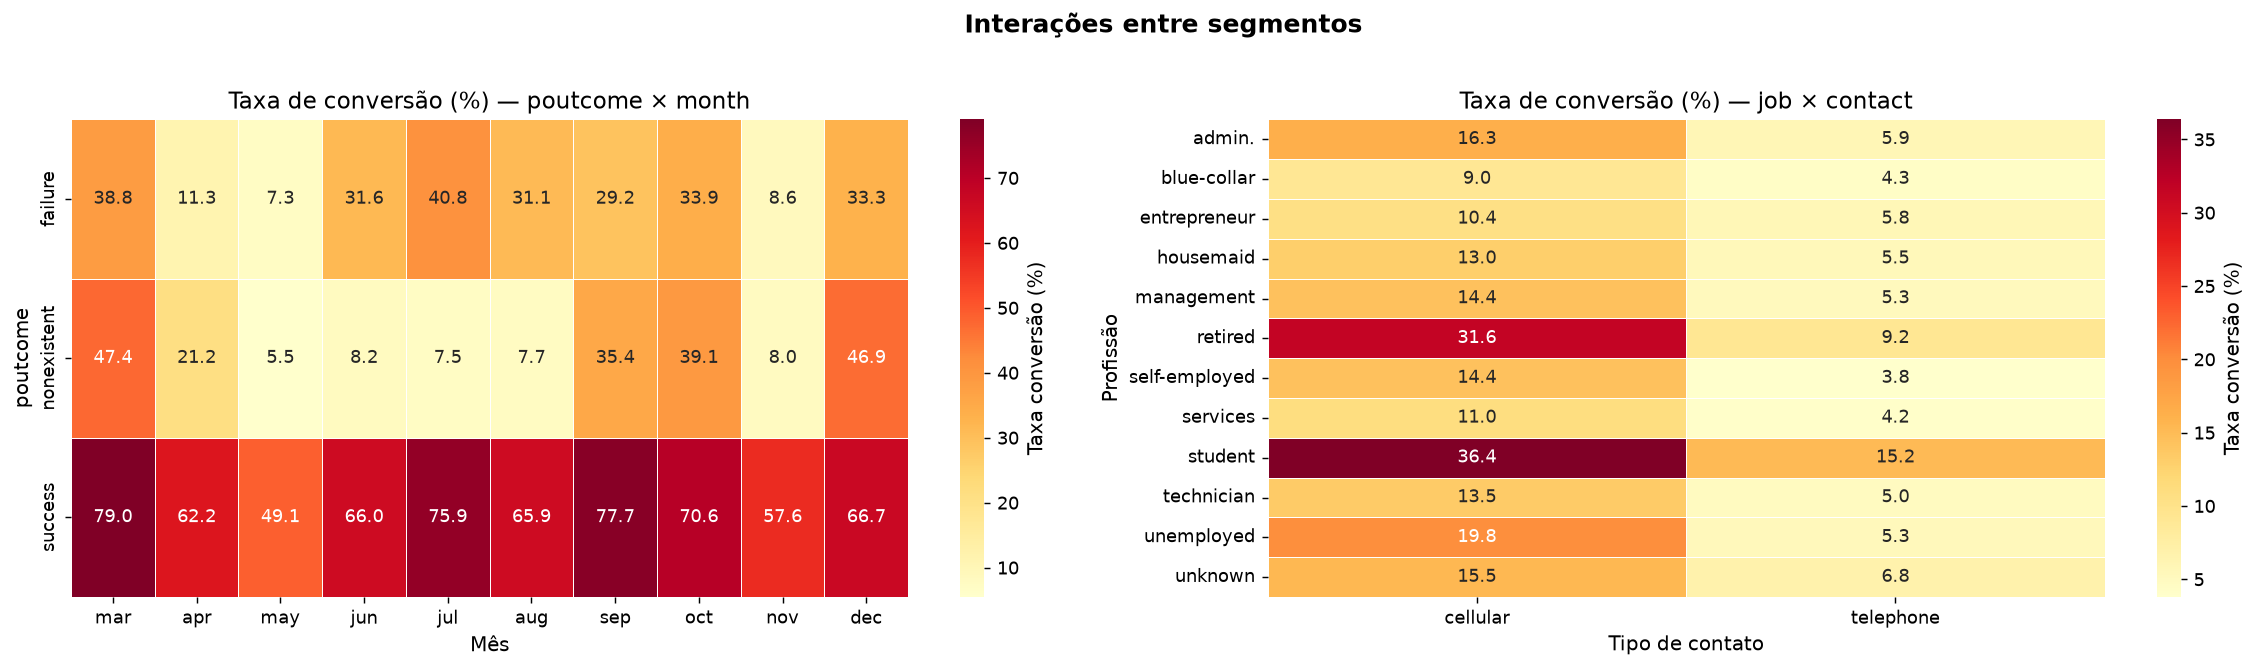

In [14]:
# Heatmap poutcome × month
pivot_pm = (df.groupby(["poutcome", "month"])["y"]
              .mean()
              .mul(100)
              .unstack(fill_value=np.nan))
 
# Ordenar meses cronologicamente
month_order = ["jan","feb","mar","apr","may","jun",
               "jul","aug","sep","oct","nov","dec"]
pivot_pm = pivot_pm.reindex(columns=[m for m in month_order if m in pivot_pm.columns])
 
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
 
sns.heatmap(pivot_pm, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=axes[0], cbar_kws={"label": "Taxa conversão (%)"})
axes[0].set_title("Taxa de conversão (%) — poutcome × month")
axes[0].set_xlabel("Mês")
axes[0].set_ylabel("poutcome")
 
# Heatmap job × contact
pivot_jc = (df.groupby(["job", "contact"])["y"]
              .mean()
              .mul(100)
              .unstack(fill_value=np.nan))
 
sns.heatmap(pivot_jc, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=axes[1], cbar_kws={"label": "Taxa conversão (%)"})
axes[1].set_title("Taxa de conversão (%) — job × contact")
axes[1].set_xlabel("Tipo de contato")
axes[1].set_ylabel("Profissão")
 
plt.suptitle("Interações entre segmentos", fontsize=14,
             fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

- **poutcome × month**
  - `poutcome=success` eleva a taxa de conversão em todos os meses, com mínimo de 49% (maio) e máximo de 79% (março).
  - Sem histórico (`nonexistent`), a variação mensal ainda é expressiva: março/outubro chegam a 47%, enquanto maio cai a 5,5%.
  - **Conclusão:** o mês por si só não prediz conversão. O contexto anterior do cliente importa muito mais.

- **job × contact**
  - `student + cellular` = 36,4% — a combinação de maior taxa no dataset.
  - Telephone é consistentemente inferior em todos os jobs, com gap médio de ~8–10 pp.
  - `student + telephone` ainda chega a 15,2%, mostrando que o perfil demográfico carrega peso mesmo com canal pior.

### C. Correlação das variáveis numéricas 

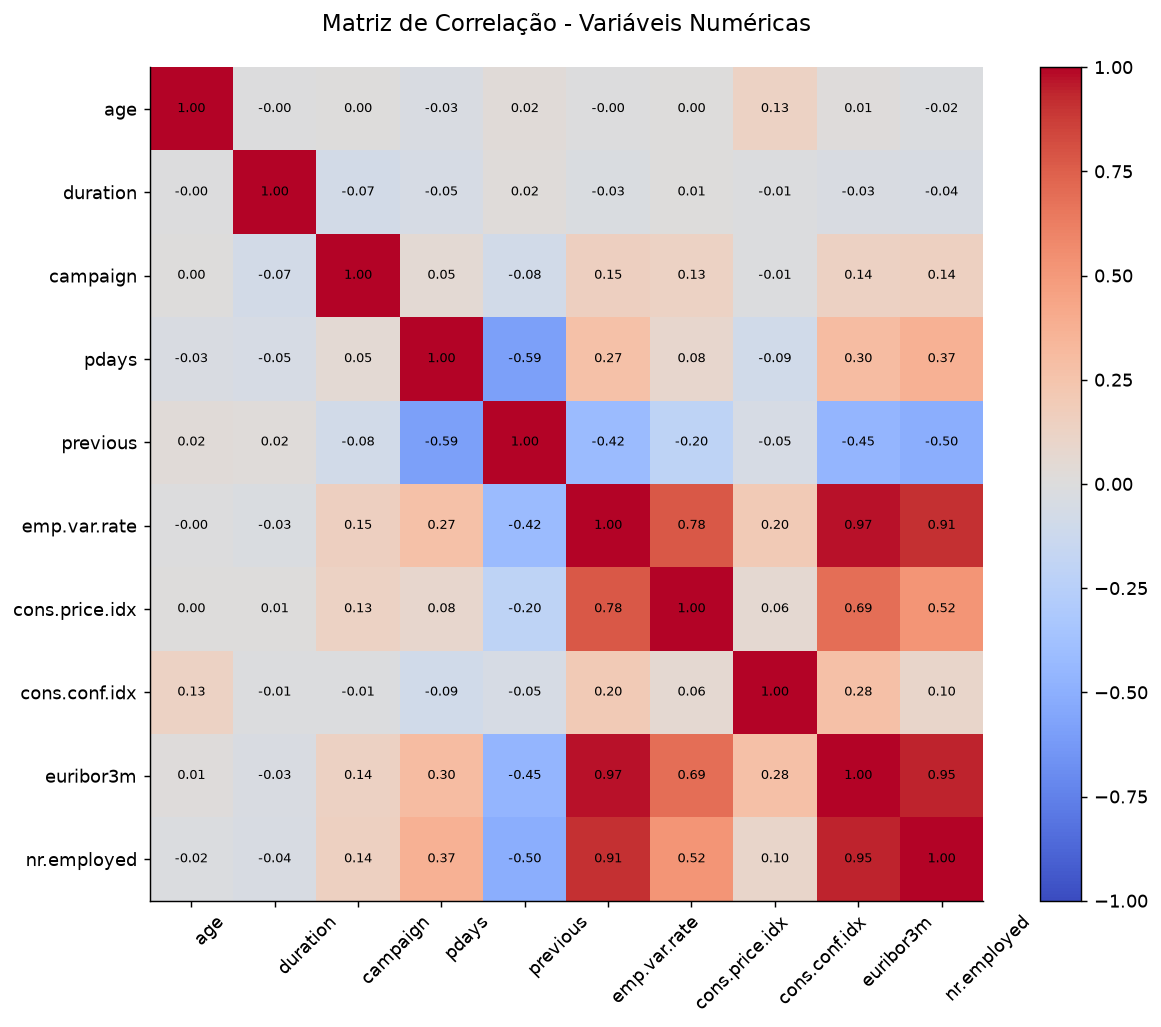

In [15]:
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))

cax = ax.matshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
fig.colorbar(cax)

# ticks
ax.set_xticks(np.arange(len(num_cols)))
ax.set_yticks(np.arange(len(num_cols)))

ax.set_xticklabels(num_cols, rotation=45, ha="left")
ax.set_yticklabels(num_cols)

ax.xaxis.set_ticks_position('bottom')
ax.tick_params(top=False, bottom=True, labeltop=False, labelbottom=True)

# valores dentro da matriz
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=7,
            color="black"
        )

plt.title("Matriz de Correlação - Variáveis Numéricas", pad=20)
plt.tight_layout()
plt.show()

- O Heatmap de correlação indica uma **multicolinearidade severa** entre variáveis macroeconômicas:
    - `emp.var.rate` × `euribor3m` = 0,97
    - `emp.var.rate` × `nr.employed` = 0,91
    - `euribor3m` × `nr.employed` = 0,95
- Logo, essas três variáveis medem essencialmente o mesmo fenômeno.
- `pdays × previous = -0,59` indica que quem foi contatado há menos tempo tende a ter mais contatos anteriores registrados.
- `cons.price.idx × emp.var.rate = 0,78` correlaciona inflação e emprego, o que é esperado macroeconomicamente.
- **Variáveis verdadeiramente independentes:** `age`, `duration` e `campaign` têm correlações baixíssimas com tudo

### D. Distribuição de variáveis numéricas por target

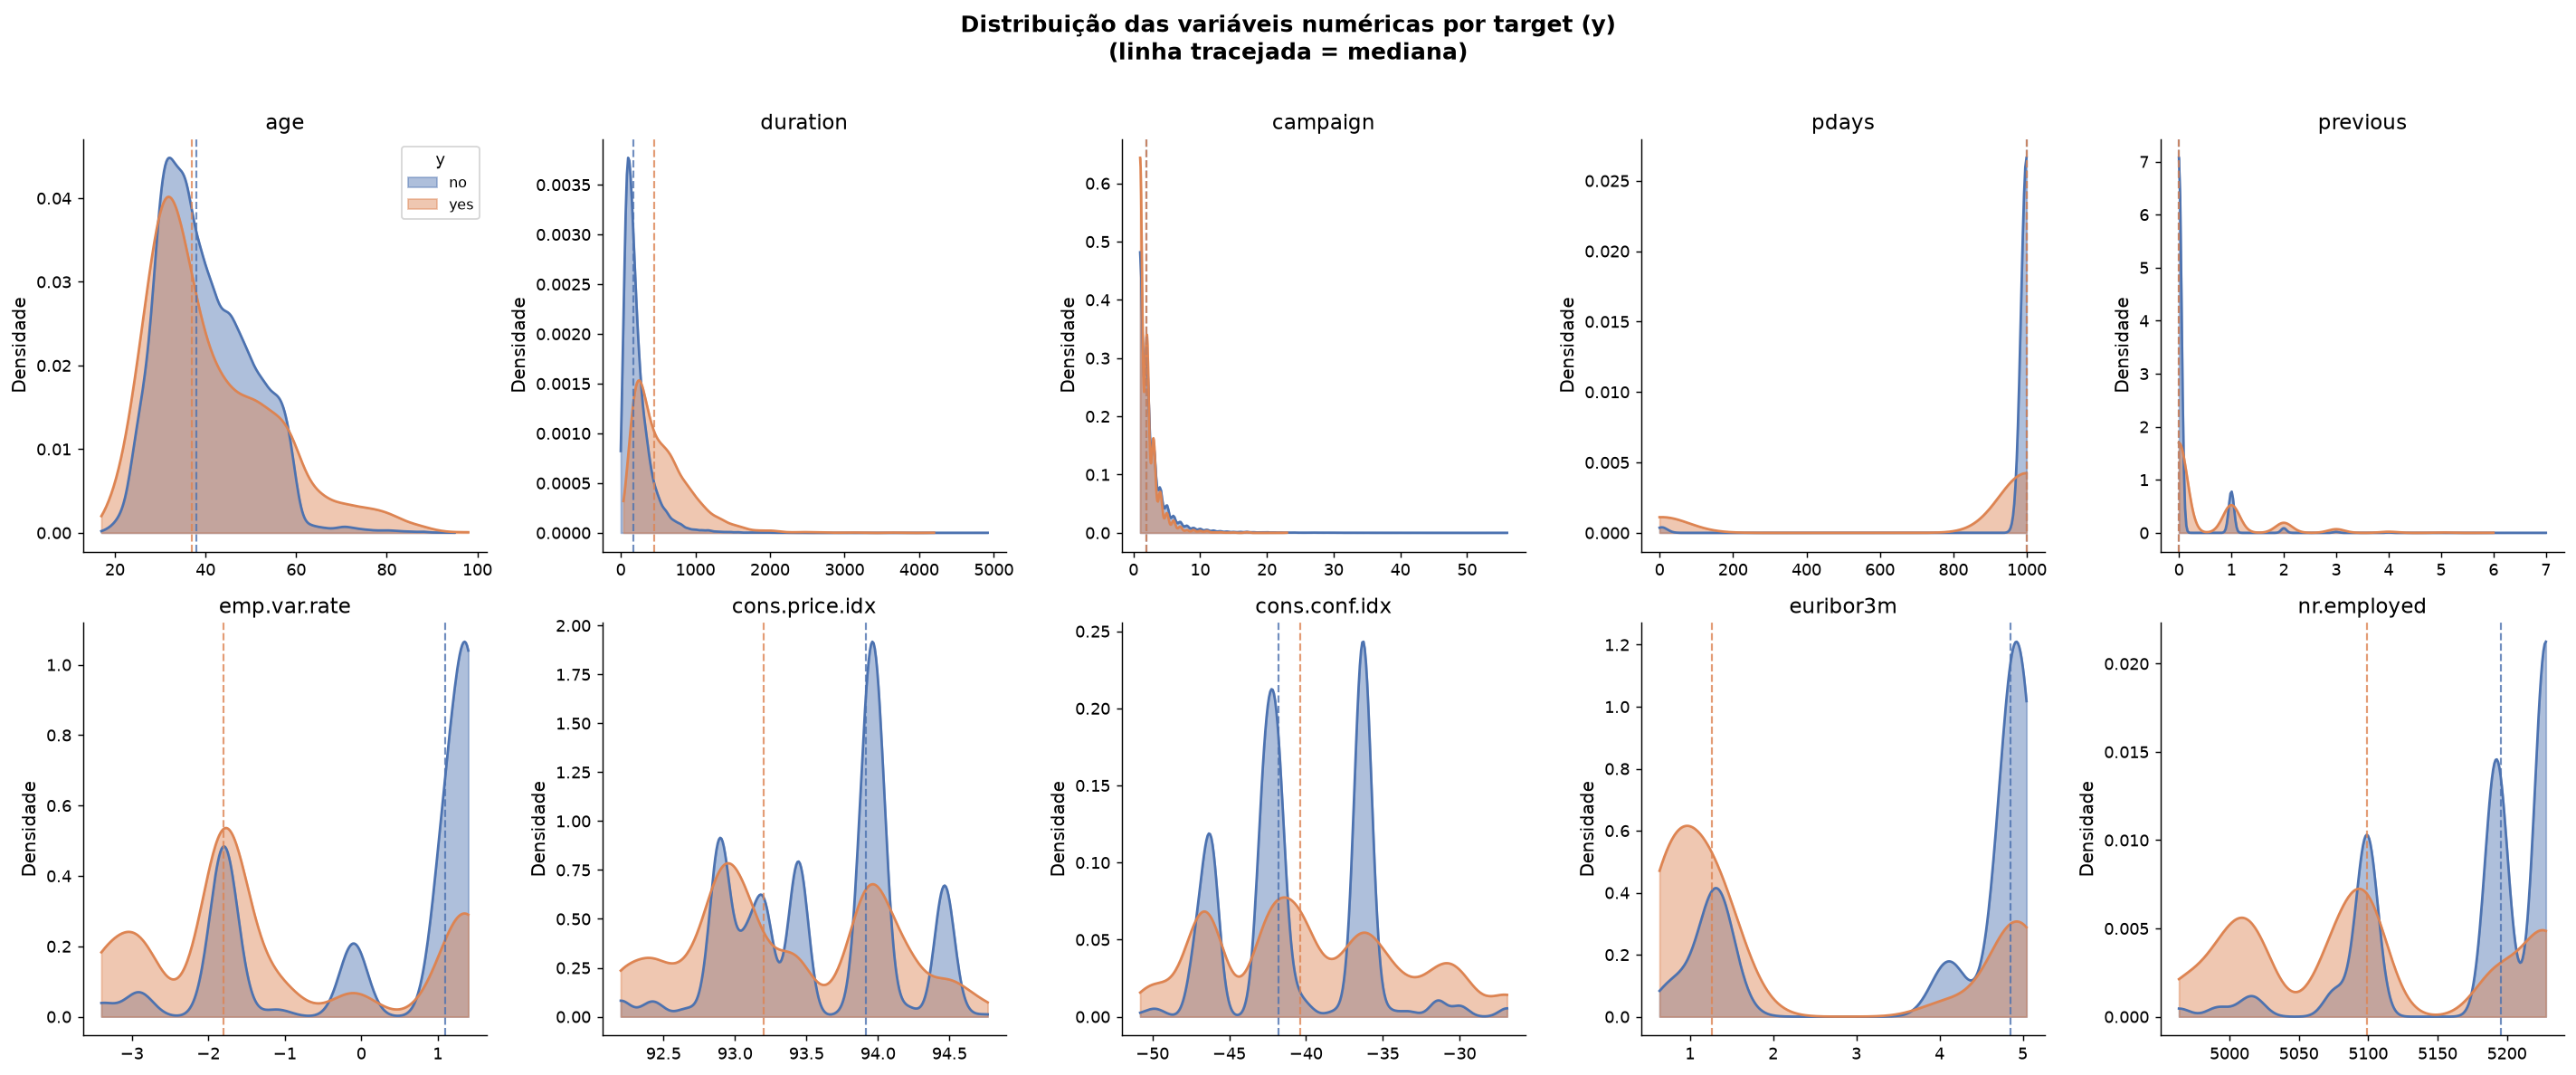

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()
palette = {0: "#4C72B0", 1: "#DD8452"}
labels = {0: "no", 1: "yes"}
 
for i, var in enumerate(num_cols):
    ax = axes[i]
    for target_val, color in palette.items():
        data = df[df["y"] == target_val][var].dropna()
        # KDE
        if data.std() > 0:
            kde_x = np.linspace(data.min(), data.max(), 300)
            kde = stats.gaussian_kde(data, bw_method="scott")
            ax.fill_between(kde_x, kde(kde_x), alpha=0.45, color=color,
                            label=labels[target_val])
            ax.plot(kde_x, kde(kde_x), color=color, linewidth=1.5)
 
    # Linha vertical para medianas
    for target_val, color in palette.items():
        med = df[df["y"] == target_val][var].median()
        ax.axvline(med, color=color, linestyle="--", linewidth=1.2, alpha=0.8)
 
    ax.set_title(var)
    ax.set_xlabel("")
    ax.set_ylabel("Densidade")
    if i == 0:
        ax.legend(title="y", fontsize=9)
 
fig.suptitle("Distribuição das variáveis numéricas por target (y)\n(linha tracejada = mediana)",
             fontsize=14, fontweight="bold", y=1.01)

plt.tight_layout()
plt.show()

- `duration` — preditor mais forte do dataset, cuja distribuição de "yes" tem cauda muito mais longa à direita: clientes convertidos tiveram ligações significativamente mais longas. A mediana de "yes" é visualmente 2–3x maior que a de "no".
- `emp.var.rate`: "yes" concentrado em valores negativos (-2 a -3), "no" concentrado em valores positivos (~1). 
  - **Conclusão**: ambientes de desemprego crescente favorecem conversão.
- `euribor3m`: "yes" concentrado em taxas baixas (1–2%), "no" em taxas altas (4–5%). 
  - **Conclusão**: juros baixos = cliente mais receptivo a investir.
- `nr.employed`: "yes" em torno de 5.000–5.100, "no" acima de 5.200.
- `cons.conf.idx`: "yes" distribuído em valores menos negativos (menos pessimista).
- `age`: distribuições muito similares, pouca separação. Não é um discriminador forte isolado
- `pdays` e `previous` — maioria dos registros em 999 (nunca contatado). O pequeno grupo com contato anterior tem leve tendência a converter mais.

### E. Análise Matriz Volume x Taxa de Conversão

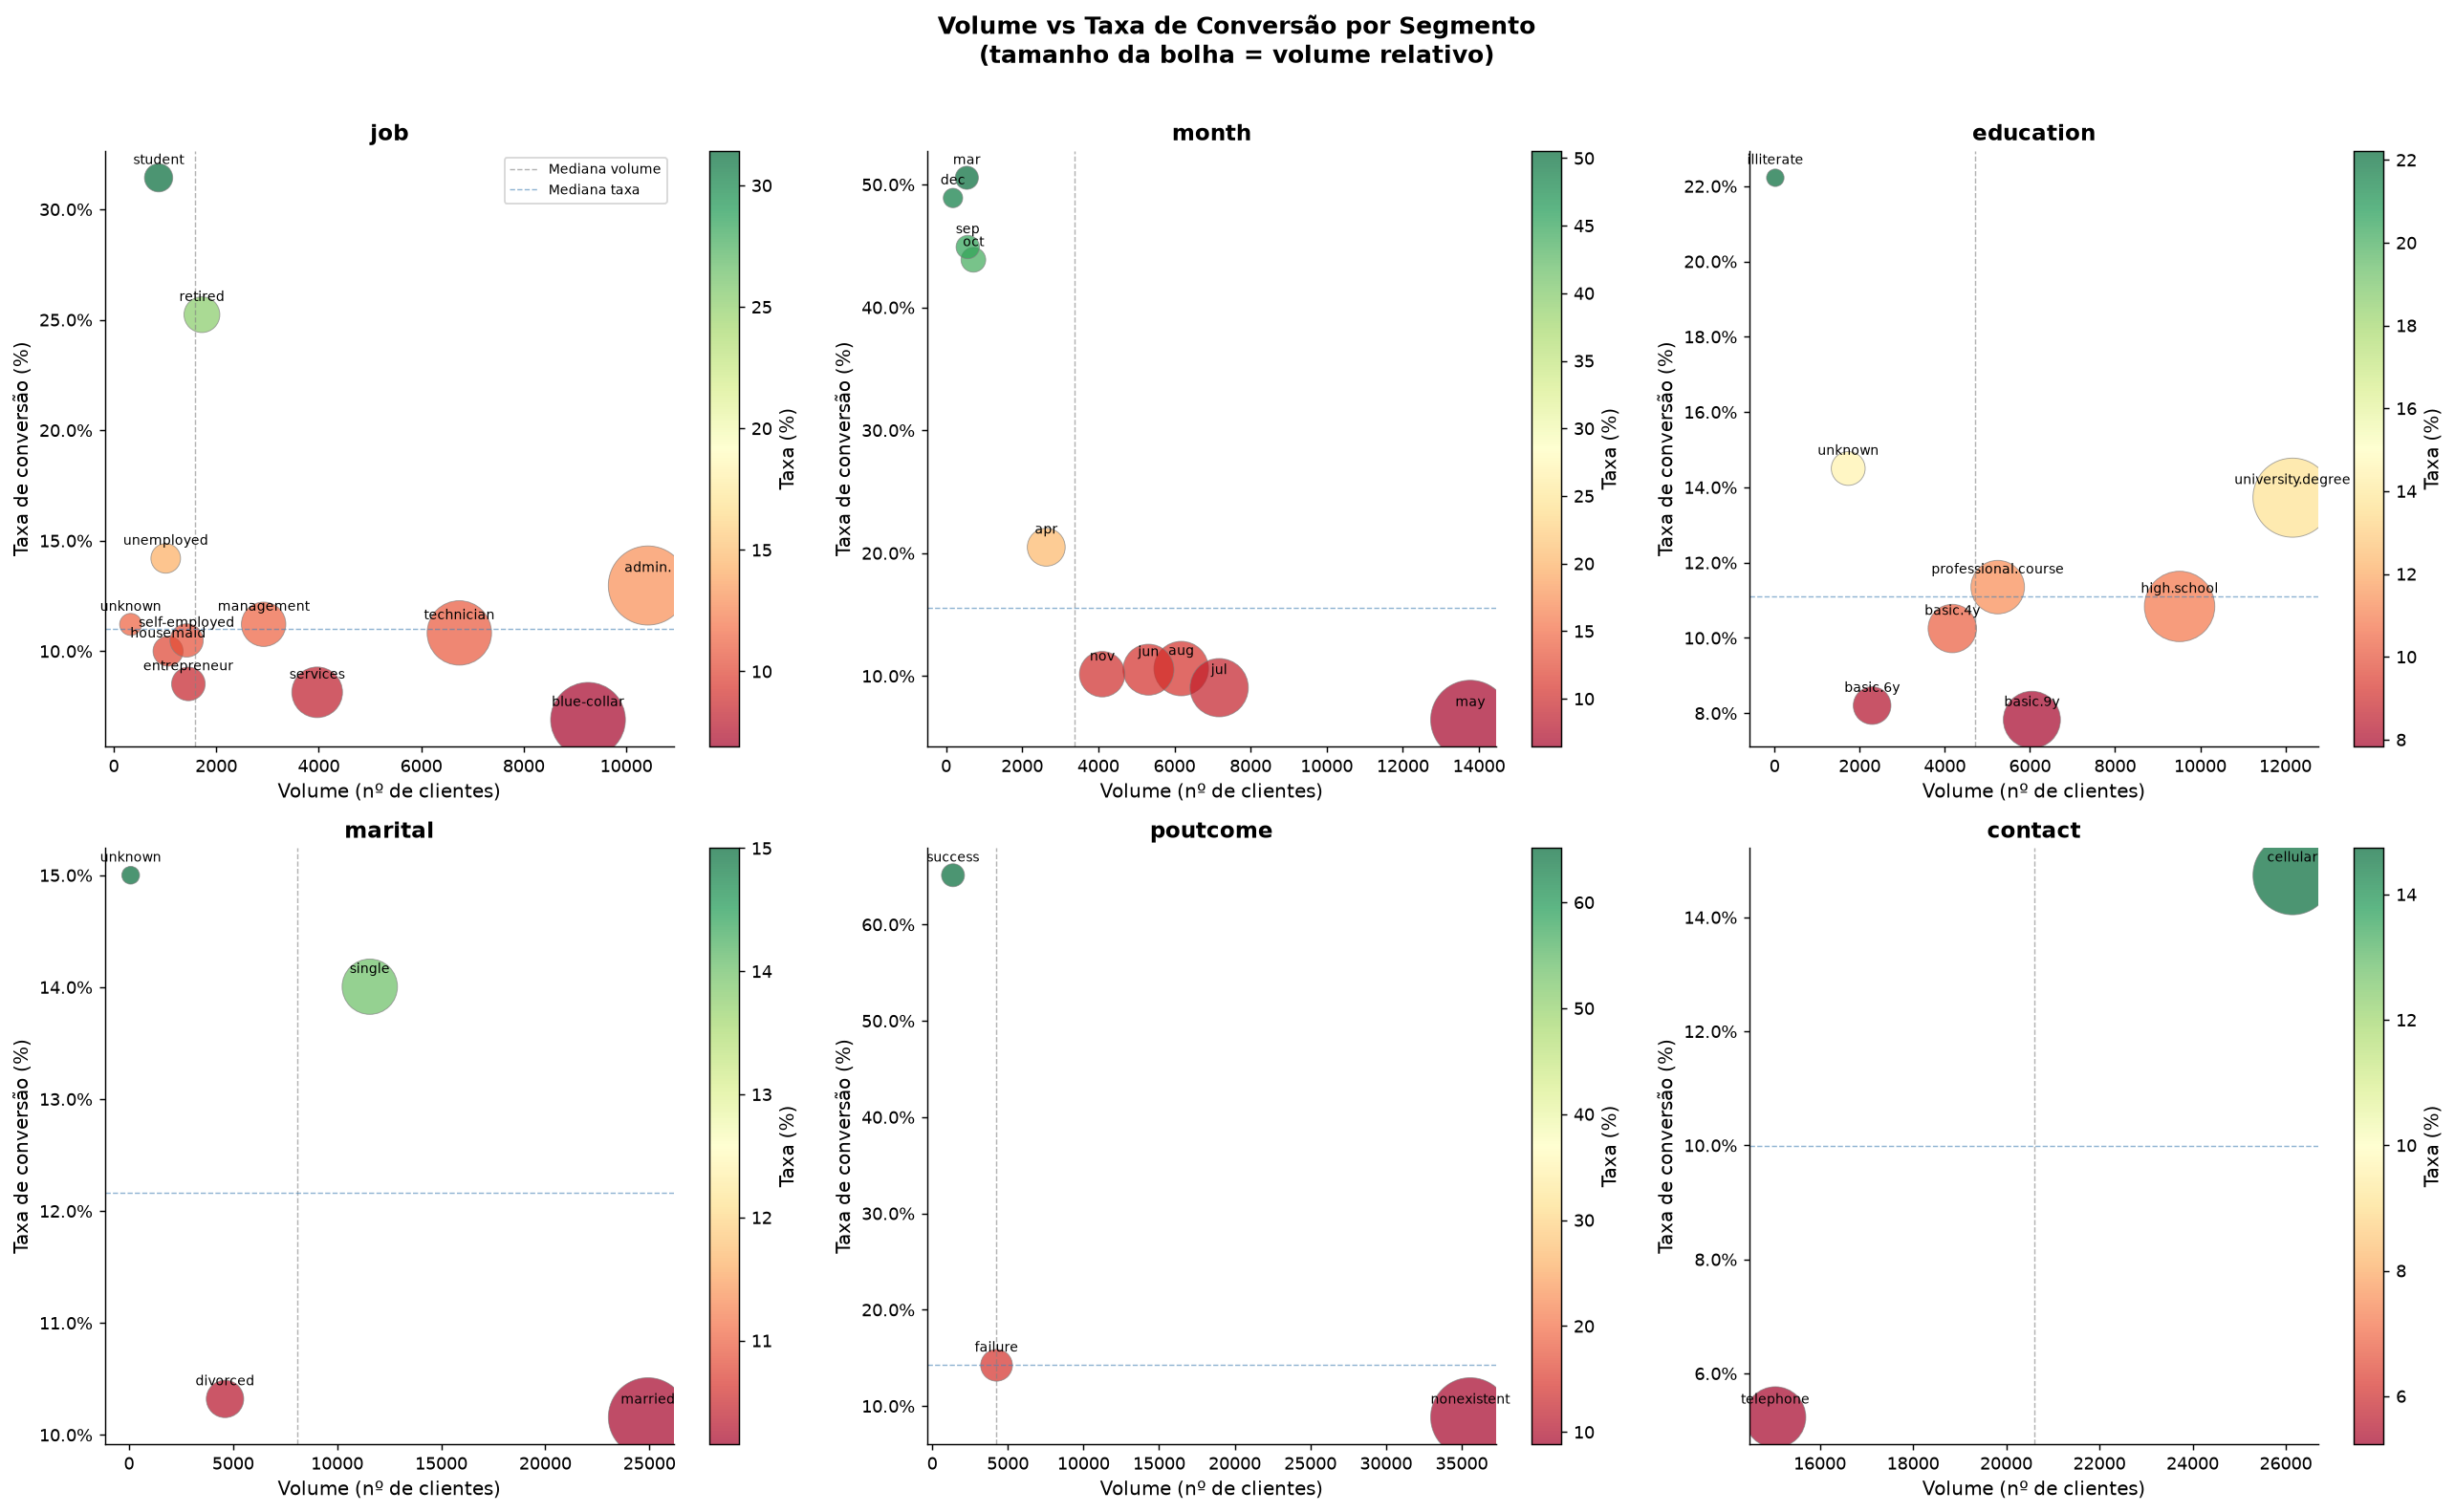

In [17]:
cat_vars_bubble = ["job", "month", "education", "marital", "poutcome", "contact"]
 
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()
 
for i, var in enumerate(cat_vars_bubble):
    ax = axes[i]
 
    agg = (df.groupby(var)["y"]
             .agg(volume="count", taxa="mean")
             .reset_index())
    agg["taxa_pct"] = agg["taxa"] * 100
 
    # Normaliza tamanho das bolhas
    size_scale = (agg["volume"] / agg["volume"].max()) * 2000 + 100
 
    scatter = ax.scatter(
        agg["volume"], agg["taxa_pct"],
        s=size_scale,
        alpha=0.7,
        c=agg["taxa_pct"],
        cmap="RdYlGn",
        edgecolors="grey",
        linewidths=0.5,
    )
 
    # Anotações
    for _, row in agg.iterrows():
        ax.annotate(
            row[var],
            (row["volume"], row["taxa_pct"]),
            fontsize=8,
            ha="center",
            va="bottom",
            xytext=(0, 6),
            textcoords="offset points",
        )
 
    # Linhas de referência (medianas)
    ax.axvline(agg["volume"].median(), color="grey", linestyle="--",
               linewidth=0.8, alpha=0.6, label="Mediana volume")
    ax.axhline(agg["taxa_pct"].median(), color="steelblue", linestyle="--",
               linewidth=0.8, alpha=0.6, label="Mediana taxa")
 
    ax.set_title(f"{var}", fontweight="bold")
    ax.set_xlabel("Volume (nº de clientes)")
    ax.set_ylabel("Taxa de conversão (%)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
 
    if i == 0:
        ax.legend(fontsize=8)
 
    plt.colorbar(scatter, ax=ax, label="Taxa (%)")
 
plt.suptitle("Volume vs Taxa de Conversão por Segmento\n"
             "(tamanho da bolha = volume relativo)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

- `job = admin` domina em volume (~10k) com taxa razoável (~13%). `student` e `retired` têm alta taxa, mas volume baixo = nicho valioso, mas limitado em escala.
- `month = may` é o maior volume do dataset (~14k), mas taxa muito baixa (~6%). **mar**, **dec**, **sep** e **oct** têm altíssima taxa, mas volume pequeno. **Indica que campanhas foram intensificadas em momentos macroeconomicamente desfavoráveis.**
- `education = illiterate` tem a maior taxa (~22%), mas volume ínfimo. `university.degree` combina volume razoável (~5k) com taxa acima da mediana, tendo, assim, o melhor custo-benefício nesse eixo.
- `poutcome = success` é a bolha ideal (alta taxa ~65%), mas `nonexistent` domina em volume (~36k) com baixa taxa. Reforça que reativar clientes com histórico positivo é a estratégia mais eficiente.
- `contact = cellular` domina em volume e taxa simultaneamente.

### F. Estabilidade Temporal

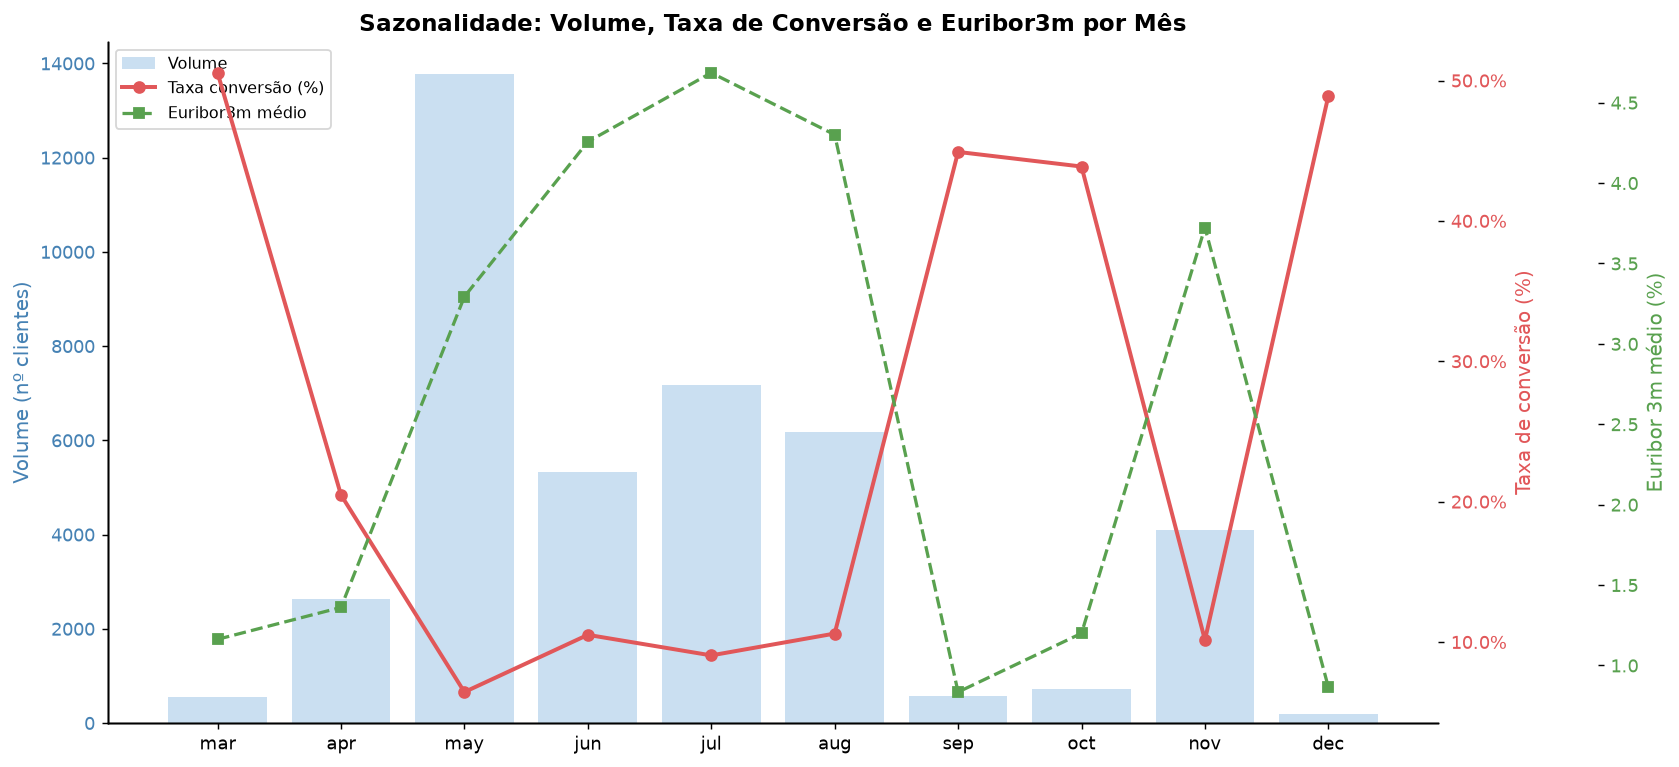

In [18]:
month_order = ["jan","feb","mar","apr","may","jun",
               "jul","aug","sep","oct","nov","dec"]
 
agg_month = (df.groupby("month")
               .agg(
                   taxa_conversao=("y", "mean"),
                   euribor3m_medio=("euribor3m", "mean"),
                   emp_var_rate=("emp.var.rate", "mean"),
                   volume=("y", "count"),
               )
               .reset_index())
 
agg_month["month"] = pd.Categorical(agg_month["month"],
                                     categories=month_order, ordered=True)
agg_month = agg_month.sort_values("month")
agg_month["taxa_pct"] = agg_month["taxa_conversao"] * 100
 
fig, ax1 = plt.subplots(figsize=(13, 6))
 
# Barras — volume
color_vol = "#BDD7EE"
ax1.bar(agg_month["month"].astype(str), agg_month["volume"],
        color=color_vol, alpha=0.8, label="Volume (eixo esq.)", zorder=1)
ax1.set_ylabel("Volume (nº clientes)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
 
# Eixo 2 — taxa de conversão
ax2 = ax1.twinx()
ax2.plot(agg_month["month"].astype(str), agg_month["taxa_pct"],
         color="#E15759", marker="o", linewidth=2.2, label="Taxa conversão (%)", zorder=3)
ax2.set_ylabel("Taxa de conversão (%)", color="#E15759")
ax2.tick_params(axis="y", labelcolor="#E15759")
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
 
# Eixo 3 — euribor3m (eixo direito adicional via anotações)
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("axes", 1.12))
ax3.plot(agg_month["month"].astype(str), agg_month["euribor3m_medio"],
         color="#59A14F", marker="s", linestyle="--",
         linewidth=1.8, label="Euribor3m médio", zorder=2)
ax3.set_ylabel("Euribor 3m médio (%)", color="#59A14F")
ax3.tick_params(axis="y", labelcolor="#59A14F")
 
# Legenda unificada
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()

patch_vol = Patch(facecolor=color_vol, alpha=0.8, label="Volume")
ax1.legend(handles=[patch_vol] + lines1 + lines2,
           loc="upper left", fontsize=9)
 
plt.title("Sazonalidade: Volume, Taxa de Conversão e Euribor3m por Mês",
          fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

- A relação inversa entre `euribor3m` e conversão é evidente:
  - **Março**: euribor baixo (~1,3%) → taxa de conversão ~50%
  - **Maio**: euribor subindo (~3,3%) → taxa despenca para ~6%
  - **Julho**: euribor no pico (~4,5%) → taxa mínima ~9%
  - **Setembro/Outubro**: euribor despenca (~1,0%) → taxa dispara para ~44%
  - **Dezembro**: euribor baixo novamente (~1,0%) → taxa volta a ~49%

- **Conclusão**: a variação mensal na taxa de conversão é quase inteiramente explicada pelo nível do euribor3m — o mês em si não é a causa, é o proxy do ambiente de juros. Isso tem implicação direta na modelagem: month como feature categórica captura um efeito que euribor3m já codifica numericamente e de forma mais rica.
- **Paradoxo de volume**: a campanha foi mais intensa exatamente nos piores meses (maio tem 14k contatos com 6% de conversão). Isso sugere que ou a estratégia de timing histórico foi equivocada, ou os dados refletem múltiplos anos com contextos distintos misturados.